# Gemma 4 Toxicity Scoring - Simplified Pipeline

Score French rap lyrics on toxicity (obscenity, violence, sexism) using Gemma 4 26B via vLLM.

**Outputs:**
- CSV with scores, metadata, and text indices
- Distribution histograms
- Temporal evolution graph (scores by year)

## Section 0: Library Imports

**Purpose:** Load all required dependencies for data processing, ML, API communication, and visualization.

**Modules loaded:**
- **Base utilities:** `csv`, `json`, `os`, `re`, `subprocess`, `sys`, `time`, `math` - for file I/O, text processing, system calls
- **Data science:** `pandas`, `numpy` - data manipulation and numerical computing
- **ML/GPU:** `torch` - CUDA device management
- **HTTP:** `requests` - API calls to vLLM endpoint
- **UI/Progress:** `tqdm`, `matplotlib` - progress bars and visualization

In [44]:
# ============================================================================
# SECTION 0: IMPORTS
# ============================================================================

# --- Magic commands pour notebooks
%matplotlib inline

# Import modules de base pour gestion fichiers, subprocess, API calls
import csv, json, os, re, subprocess, sys, time, math
from pathlib import Path

# Import data science & ML
import pandas as pd
import numpy as np
import torch

# Import HTTP client pour requêtes vLLM API
import requests

# Import UI/Viz
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("✓ Tous les imports sont chargés")

✓ Tous les imports sont chargés


## Section 1: Global Configuration

**Purpose:** Set all runtime parameters for model inference, resource allocation, file paths, and sampling strategy.

**Key configurations:**
- **Model & GPU:** Gemma-4-26B-A4B on GPU 3, vLLM OpenAI-compatible server on port 8012
- **Sampling:** 0.1% of corpus (~85 documents) with word count filter (10-4000 words)
- **Inference params:** Temperature=0 (deterministic), max_tokens=128, 180s timeout
- **Resource management:** 88% GPU memory utilization, BF16 precision, 1 tensor-parallel replica
- **Output structure:** Organized batch directories with run label for traceability

In [45]:
# ============================================================================
# SECTION 1: GLOBAL CONFIGURATION - Tous les paramètres centralisés
# ============================================================================

# --- Identifiant run
notebook_prefix = 'R03'
sample_label = 'full_10to4000w'

# --- Modèle & GPU
model_name = 'mistralai/Mistral-7B-Instruct-v0.3'
gpu_index = 3
server_port = 8013

# --- Chemins
home = Path.home()
model_base = home / '.cache/huggingface/hub/models--mistralai--Mistral-7B-Instruct-v0.3/snapshots'
model_path = model_base
if model_base.exists():
    snapshots = sorted(model_base.glob('*'))
    if snapshots:
        model_path = snapshots[0]

vllm_python = home / 'miniconda3/envs/vllm_mistral/bin/python'
vllm_library_dir = home / 'miniconda3/envs/vllm_mistral/lib/python3.11/site-packages/vllm'

corpus_path = Path('corpus.csv')
export_dir = Path('export')
parts_dir = export_dir / f'{notebook_prefix}_{sample_label}_parts'

export_dir.mkdir(exist_ok=True)
parts_dir.mkdir(exist_ok=True)

# --- Sampling & Filtering
min_words_per_document = 10
max_words_per_document = 4000
pilot_fraction = 1.00  # full corpus after validation
random_state = 42

# --- Inference settings
documents_per_batch = 100
max_retries = 2
request_timeout_seconds = 180

# --- vLLM server settings
gpu_memory_utilization = 0.88
max_model_len = 12288  # Context window
gpu_memory_utilization = 0.60
max_model_len = 8192  # Context window
base_url = f'http://127.0.0.1:{server_port}'
models_url = f'{base_url}/v1/models'

# --- Logs
server_log_path = export_dir / f'{notebook_prefix}_{sample_label}_vllm_server.log'
run_label = f'{model_name.split("/")[-1].lower()}_{sample_label}'

print("="*70)
print(f"✓ Configuration chargée")
print(f"  Model: {model_name}")
print(f"  GPU: {gpu_index}")
print(f"  Server: {base_url}")
print(f"  Corpus: {corpus_path}")
print(f"  Export: {export_dir}")
print(f"  Sample: {pilot_fraction:.2%}")
print("="*70)

✓ Configuration chargée
  Model: mistralai/Mistral-7B-Instruct-v0.3
  GPU: 3
  Server: http://127.0.0.1:8013
  Corpus: corpus.csv
  Export: export
  Sample: 100.00%


In [46]:
# ============================================================================
# SECTION 2: DÉMARRAGE SERVEUR vLLM
# ============================================================================

def endpoint_is_healthy():
    """
    Vérifier si endpoint vLLM est sain et accessible.
    
    Retour:
        bool: True si /v1/models répond avec OK, False sinon
    """
    try:
        response = requests.get(models_url, timeout=5)
        return response.ok
    except requests.RequestException:
        return False

# --- 2.1: Vérifier si serveur est déjà actif
print("🔍 Vérifying vLLM endpoint health...")
if endpoint_is_healthy():
    print("✓ vLLM serveur déjà actif")
else:
    # --- 2.2: Démarrer serveur vLLM en arrière-plan
    print("🚀 Starting vLLM server on GPU", gpu_index)
    torch.cuda.set_device(gpu_index)
    
    # Construction commande serveur
    server_command = [
        str(vllm_python), '-m', 'vllm.entrypoints.openai.api_server',
        '--model', str(model_path),
        '--served-model-name', model_name,
        '--host', '127.0.0.1',
        '--port', str(server_port),
        '--tensor-parallel-size', '1',          # Pas de parallélisation (1 GPU)
        '--dtype', 'bfloat16',                  # Format bfloat16 pour économie mém
        '--gpu-memory-utilization', str(gpu_memory_utilization),
        '--max-model-len', str(max_model_len),  # Limit context window
        '--no-enable-log-requests',             # Pas de logging verbose
    ]
    
    # Configuration variables d'environnement
    server_environment = {
        **os.environ,
        'CUDA_VISIBLE_DEVICES': str(gpu_index),  # Réserver GPU spécifique
        # Ne pas forcer LD_PRELOAD sur le système global : il casse le runtime vLLM déjà compatible.
        'LD_LIBRARY_PATH': f"{vllm_library_dir}:{os.environ.get('LD_LIBRARY_PATH', '')}",
    }
    
    # --- 2.3: Lancer processus vLLM avec logging
    with server_log_path.open('a', encoding='utf-8') as log:
        server_process = subprocess.Popen(
            server_command,
            stdout=log,
            stderr=subprocess.STDOUT,
            env=server_environment,
        )
    
    # --- 2.4: Attendre que serveur soit sain (max 15 min)
    print(f"⏳ Waiting for vLLM to start...")
    startup_deadline = time.monotonic() + 900  # 15 minutes
    while time.monotonic() < startup_deadline:
        if endpoint_is_healthy():
            print(f"✓ vLLM server healthy at {base_url}")
            break
        if server_process.poll() is not None:
            raise RuntimeError('vLLM process crashed during startup')
        time.sleep(5)
    else:
        raise TimeoutError('vLLM failed to start within 15 minutes')

🔍 Vérifying vLLM endpoint health...
✓ vLLM serveur déjà actif


## Section 2: vLLM Server Startup & Health Monitoring

**Purpose:** Launch Gemma-4-26B inference server and wait until it becomes ready for scoring requests.

**Workflow:**
1. **Health check:** Ping `/v1/models` endpoint to see if server already running
2. **If needed:** Start vLLM subprocess with GPU isolation, BF16 precision, and optimized memory settings
3. **Polling:** Check endpoint every 5 seconds, timeout after 15 minutes
4. **Safety:** Detect if process crashes during startup and raise error

**Output:** Endpoint is healthy at `http://127.0.0.1:8012`

In [47]:
# ============================================================================
# SECTION 3: CHARGEMENT & FILTRAGE CORPUS
# ============================================================================

# --- 3.1: Charger CSV corpus avec fallback encodage
print("📖 Loading corpus from", corpus_path)
try:
    corpus_df = pd.read_csv(corpus_path, encoding='utf-8', on_bad_lines='skip')
except UnicodeDecodeError:
    print("  ⚠️  UTF-8 failed, trying latin-1")
    corpus_df = pd.read_csv(corpus_path, encoding='latin-1', on_bad_lines='skip')

print(f"  ✓ Loaded {len(corpus_df):,} documents")

# --- 3.2: Valider colonnes requises
text_column = 'lyrics'
metadata_columns = ['doc_id', 'artist', 'title', 'year', 'url']

if 'doc_id' not in corpus_df.columns:
    raise KeyError(f'❌ doc_id not found. Available: {corpus_df.columns.tolist()}')
if text_column not in corpus_df.columns:
    raise KeyError(f'❌ {text_column} not found. Available: {corpus_df.columns.tolist()}')

print(f"  ✓ Colonnes requises présentes: {metadata_columns}")

# --- 3.3: Ajouter index source pour traçabilité
corpus_df = corpus_df.reset_index(drop=True)
corpus_df.insert(1, 'source_row_index', range(len(corpus_df)))
print(f"  ✓ source_row_index ajouté")

# --- 3.4: Calculer word_count et filtrer documents éligibles
text_values = corpus_df[text_column].fillna('').astype(str).str.strip()
word_counts = text_values.str.split().str.len()

# Critères éligibilité: word_count entre min et max
eligible_mask = word_counts.between(min_words_per_document, max_words_per_document, inclusive='both')
eligible_df = corpus_df.loc[eligible_mask].copy()
eligible_df['word_count'] = word_counts.loc[eligible_mask]

print(f"\n📊 Corpus filtering:")
print(f"  - Total documents: {len(corpus_df):,}")
print(f"  - Filtered out (word count): {(~eligible_mask).sum():,}")
print(f"  - Eligible documents: {len(eligible_df):,}")

# --- 3.5: Sélectionner sample aléatoire du corpus éligible
selected_df = eligible_df.sample(
    frac=pilot_fraction,
    random_state=random_state,
).sort_values('source_row_index').copy()

print(f"\n🎯 Sample selection ({int(pilot_fraction*100)}%):")
print(f"  - Selected documents: {len(selected_df):,}")
print(f"  - Batch size: {documents_per_batch}")
total_batches = math.ceil(len(selected_df) / documents_per_batch)
print(f"  - Total batches: {total_batches}")

# --- 3.6: Fonction helper pour accès fichiers batch
def batch_path(batch_idx):
    """Retourner chemin fichier CSV pour batch donné (zéro-padded 5 chiffres)."""
    return parts_dir / f'part_{batch_idx:05d}.csv'

print(f"  ✓ Batch output template: {batch_path(0).name}")

📖 Loading corpus from corpus.csv


  ✓ Loaded 85,023 documents
  ✓ Colonnes requises présentes: ['doc_id', 'artist', 'title', 'year', 'url']
  ✓ source_row_index ajouté

📊 Corpus filtering:
  - Total documents: 85,023
  - Filtered out (word count): 868
  - Eligible documents: 84,155

🎯 Sample selection (100%):
  - Selected documents: 84,155
  - Batch size: 100
  - Total batches: 842
  ✓ Batch output template: part_00000.csv


## Section 3: Corpus Loading & Filtering

**Purpose:** Load lyrics dataset, validate structure, filter by word count, and prepare sampling strategy.

**Data pipeline:**
1. **Load CSV:** UTF-8 encoding with fallback to latin-1 for robustness
2. **Validate columns:** Ensure `doc_id`, `lyrics` (and optional metadata) present
3. **Add traceability:** Insert `source_row_index` for corpus position tracking
4. **Filter eligibility:** Keep only documents with 10-4000 words (removes spam, extremely short/long texts)
5. **Random sampling:** Select 0.1% fraction with fixed seed for reproducibility
6. **Batch organization:** Split into ~85 documents across 1 batch for scoring

**Result:** Selected documents sorted by source index, ready for toxicity scoring

In [48]:
# --- 4.0: Définitions des critères de toxicité
TOXICITY_CRITERIA = {
    'obscenity': 'mots ou expressions grossières, vulgaires ou insultantes',
    'violence': 'mots ou expressions de violence, agression, menace ou brutalité',
    'sexism': 'mots ou expressions sexistes, misogynes, humiliantes ou dévalorisant le genre',
    'stigmatization': 'mots ou expressions stigmatisantes, discriminatoires ou dévalorisant un groupe social',
}

# --- 4.1: Clamp score values to valid range
def clamp_score(value_str, min_val=0, max_val=10):
    """Parse string score, handle French decimals (1,5 -> 1.5), clamp to range."""
    if not value_str or pd.isna(value_str):
        return None
    
    value_str = str(value_str).strip().replace(',', '.')
    try:
        val = float(value_str)
        val = max(min_val, min(max_val, val))
        return int(val) if val == int(val) else val
    except (ValueError, TypeError):
        return None


# --- 4.2: Parse toxicity scores from text with multi-level fallback
def parse_toxicity_scores(content):
    """
    Parse 4 scores from LLM response text.
    
    Returns dict: {'obscenity': X, 'violence': Y, 'sexism': Z, 'stigmatization': W}
    with None for missing scores.
    
    Fallback strategy:
      Level 1: Regex "Criterion: number" pattern (case-insensitive)
      Level 2: Extract 4 sequential numbers from text if Level 1 fails
    """
    scores_dict = {'obscenity': None, 'violence': None, 'sexism': None, 'stigmatization': None}
    criteria_keys = list(scores_dict.keys())
    
    if not content or not str(content).strip():
        return scores_dict
    
    content_str = str(content).strip()
    
    # Level 1: Regex pattern matching "Criterion: number" (case-insensitive)
    for criterion in criteria_keys:
        # Pattern: "Obscenity: 7" or "obscenity:7" or "Obscenity : 7"
        pattern = rf'{criterion}\s*:\s*(\d+(?:[.,]\d+)?)'
        match = re.search(pattern, content_str, re.IGNORECASE)
        if match:
            score_str = match.group(1)
            scores_dict[criterion] = clamp_score(score_str)
    
    # Level 2: If Level 1 failed entirely, try extracting 4 numbers sequentially
    if all(v is None for v in scores_dict.values()):
        numbers = re.findall(r'\d+', content_str)
        if len(numbers) >= 4:
            for i, criterion in enumerate(criteria_keys):
                scores_dict[criterion] = clamp_score(numbers[i])
    
    return scores_dict


# --- 4.3: Appel API vLLM - UN SEUL appel pour TOUS les critères
def score_lyrics_all_criteria(lyrics):
    """
    Scorer paroles sur TOUS les critères (obscenity, violence, sexism, stigmatization)
    avec UN SEUL appel API.
    
    Stratégie simple:
      1. Prompt ultra-simple en français
      2. Demander 4 scores 0-10
      3. Parser avec regex robuste
    
    Args:
        lyrics: Texte paroles (str, truncate à 1500 chars)
    
    Returns:
        tuple: (scores_dict, num_attempts, raw_response)
               scores_dict: {'obscenity': X, 'violence': Y, 'sexism': Z, 'stigmatization': W}
               num_attempts: Nombre tentatives effectuées
               raw_response: Réponse brute du LLM
    """
    url = f'{base_url}/v1/completions'
    
    # Construire prompt ultra-simple
    criteria_descriptions = '\n'.join([
        f"- {key.capitalize()}: {desc}"
        for key, desc in TOXICITY_CRITERIA.items()
    ])
    
    prompt = f'''Évalue le texte suivant sur 4 critères de toxicité (échelle 0-10).
En t'appuyant sur l'analyse du lexique, identifie et compte les mots/expressions toxiques.

Texte:
{lyrics[:1500]}

Critères:
{criteria_descriptions}

Méthode d'analyse:
- Identifie les mots/expressions spécifiques à chaque critère
- Compte leur fréquence et distribution dans le texte
- Évalue sur l'échelle 0-10: absence=0, rare=2-3, quelques instances=4-6, fréquent=7-8, omniprésent=9-10

Retourne SIMPLEMENT les 4 scores sur une ligne:
Obscenity: [score] Violence: [score] Sexism: [score] Stigmatization: [score]

Réponse:'''
    
    payload = {
        'model': model_name,
        'prompt': prompt,
        'temperature': 0,
        'max_tokens': 64,  # Réponse courte seulement
    }
    
    last_error = None
    for attempt in range(1, max_retries + 2):
        try:
            response = requests.post(url, json=payload, timeout=request_timeout_seconds)
            response.raise_for_status()
            
            try:
                response_json = response.json()
                text = response_json.get('choices', [{}])[0].get('text', '').strip()
            except (json.JSONDecodeError, KeyError, IndexError, TypeError):
                last_error = "Response parse error"
                continue
            
            if not text:
                last_error = "Empty response"
                continue
            
            # Parser scores
            scores = parse_toxicity_scores(text)
            
            # Vérifier si au moins UN score a été trouvé
            if any(v is not None for v in scores.values()):
                return scores, attempt, text
            else:
                last_error = f"No scores found in: {text[:100]}"
        
        except requests.Timeout:
            last_error = "Timeout"
        except requests.ConnectionError:
            last_error = "Connection error"
        except requests.HTTPError as e:
            last_error = f"HTTP {response.status_code}"
        except Exception as e:
            last_error = str(type(e).__name__)
    
    # Retourner vide si tout échoue
    return {'obscenity': None, 'violence': None, 'sexism': None, 'stigmatization': None}, \
           max_retries + 1, last_error


print("✓ Fonctions de scoring simplifiées et robustes chargées")

✓ Fonctions de scoring simplifiées et robustes chargées


## Section 4: Toxicity Scoring Functions

**Purpose:** Define robust parsing and scoring pipeline with multi-level fallback strategy.

**Function stack:**

### 4.1 `clamp_score(value_str, min_val=0, max_val=10)`
- Parse string representations of scores (handles French comma decimals)
- Clamp values to valid range [0, 10]
- Return None for missing/invalid data

### 4.2 `extract_fields_from_text(raw_text)`
- Use regex patterns to extract toxicity scores from unstructured text
- Support alternative field names (insult→obscenity, threat→violence, racism→sexism)
- Case-insensitive matching for robustness

### 4.3 `parse_scores(content)` - **Multi-level fallback strategy**
- **Level 1 (JSON):** Extract `{obscenity: X, violence: Y, sexism: Z}` blocks
- **Level 2 (Regex):** If JSON fails, use pattern matching on raw text
- **Level 3 (Failure):** Return all None scores if both methods fail
- Returns tuple: (scores_dict, parse_level_name)

### 4.4 `score_lyrics(lyrics)`
- Send lyrics to vLLM API with structured prompt requesting JSON response
- Parse response with fallback strategy (JSON → Regex → Failure)
- Implement retry loop (up to 3 attempts if parsing fails)
- Return: scores, num_attempts, raw_response, parse_level

**Design principle:** Graceful degradation - always produce output, never crash

In [49]:
# ============================================================================
# SECTION 5: MAIN SCORING LOOP - UN SEUL APPEL PAR DOCUMENT
# ============================================================================

print("\n" + "="*70)
print(f"🎯 SCORING {len(selected_df):,} documents (UN appel par doc)")
print(f"   Total API calls: {len(selected_df):,} (vs {len(selected_df)*4:,} avant)")
print("="*70 + "\n")

# Progress bar
overall_pbar = tqdm(
    total=len(selected_df),
    desc="Scoring progress",
    unit='docs'
)

# Itérer sur chaque batch
for batch_idx in range(total_batches):
    # --- 5.1: Extraire documents du batch
    batch_start = batch_idx * documents_per_batch
    batch_end = min(batch_start + documents_per_batch, len(selected_df))
    batch_docs = selected_df.iloc[batch_start:batch_end].copy()
    
    # --- 5.2: Boucle documents - UN SEUL appel par doc pour 4 critères
    batch_results = []
    for row_idx, (_, row) in enumerate(batch_docs.iterrows()):
        doc_id = row['doc_id']
        lyrics_text = row[text_column]
        
        # Initialiser résultats
        result_row = {
            'doc_id': doc_id,
            'source_row_index': row['source_row_index'],
            'artist': row.get('artist', ''),
            'title': row.get('title', ''),
            'year': row.get('year', ''),
            'word_count': row.get('word_count', 0),
        }
        
        # --- 5.3: UN SEUL appel API pour TOUS les critères
        scores_dict, num_attempts, raw_response = score_lyrics_all_criteria(lyrics_text)
        
        # Stocker tous les scores
        for criterion_key, score_val in scores_dict.items():
            result_row[criterion_key] = score_val
        
        result_row['raw_response'] = raw_response
        result_row['attempts'] = num_attempts
        
        batch_results.append(result_row)
        overall_pbar.update(1)
    
    # --- 5.4: Exporter batch en CSV
    batch_df = pd.DataFrame(batch_results)
    batch_file = batch_path(batch_idx)
    batch_df.to_csv(batch_file, index=False)
    
    print(f"✓ Batch {batch_idx+1:2d}/{total_batches}: {len(batch_df):3d} docs → {batch_file.name}")

overall_pbar.close()
print(f"\n✓ Scoring complété - {total_batches} batch files générés")
print(f"✓ API calls: {len(selected_df):,} (réduction de 75%!)")


🎯 SCORING 84,155 documents (UN appel par doc)
   Total API calls: 84,155 (vs 336,620 avant)



Scoring progress:   0%|          | 0/84155 [00:00<?, ?docs/s]

✓ Batch  1/842: 100 docs → part_00000.csv
✓ Batch  2/842: 100 docs → part_00001.csv
✓ Batch  3/842: 100 docs → part_00002.csv
✓ Batch  4/842: 100 docs → part_00003.csv
✓ Batch  5/842: 100 docs → part_00004.csv
✓ Batch  6/842: 100 docs → part_00005.csv
✓ Batch  7/842: 100 docs → part_00006.csv
✓ Batch  8/842: 100 docs → part_00007.csv
✓ Batch  9/842: 100 docs → part_00008.csv
✓ Batch 10/842: 100 docs → part_00009.csv
✓ Batch 11/842: 100 docs → part_00010.csv
✓ Batch 12/842: 100 docs → part_00011.csv
✓ Batch 13/842: 100 docs → part_00012.csv
✓ Batch 14/842: 100 docs → part_00013.csv
✓ Batch 15/842: 100 docs → part_00014.csv
✓ Batch 16/842: 100 docs → part_00015.csv
✓ Batch 17/842: 100 docs → part_00016.csv
✓ Batch 18/842: 100 docs → part_00017.csv
✓ Batch 19/842: 100 docs → part_00018.csv
✓ Batch 20/842: 100 docs → part_00019.csv
✓ Batch 21/842: 100 docs → part_00020.csv
✓ Batch 22/842: 100 docs → part_00021.csv
✓ Batch 23/842: 100 docs → part_00022.csv
✓ Batch 24/842: 100 docs → part_00

## Section 5: Main Scoring Loop - Double Loop (Documents × Criteria)

**Purpose:** Orchestrate batch processing with independent criterion evaluation via nested loops.

**Key Innovation - Double Loop Architecture:**
```
For each batch:
    For each document in batch:
        results = {}
        For each toxicity criterion ['obscenity', 'violence', 'sexism', 'stigmatization']:
            - Call API with criterion-specific prompt
            - Parse score (0-10)
            - Store result
        Export row with 4 score columns
```

**Advantages:**
- **Independent evaluation:** Each criterion is scored separately, avoiding bias between dimensions
- **Fine-grained assessment:** Nuanced understanding of which toxicity types are present
- **Cleaner parsing:** Each API call returns 1 score instead of 3 (more robust)
- **Flexibility:** Easy to add/remove criteria or adjust prompts per criterion

**Workflow:**
1. **Batch iteration:** Process documents in groups of 100
2. **Per-document, per-criterion:** Make 4 API calls (one per criterion)
3. **Result capture:** Record all 4 scores + metadata
4. **Intermediate export:** Save each batch as CSV
5. **Progress tracking:** Display nested progress (documents × criteria)

**Output structure:** One CSV per batch with columns: doc_id, artist, title, year, word_count, obscenity, violence, sexism, stigmatization, num_attempts_*, parse_level_*

In [50]:
# ============================================================================
# SECTION 6: AGRÉGATION & DIAGNOSTIC RÉSULTATS
# ============================================================================

print("\n" + "="*70)
print("🔗 AGGREGATING results from batch files")
print("="*70)

# --- 6.1: Charger et concaténer tous les batches
all_batch_dfs = []
for batch_idx in range(total_batches):
    batch_file = batch_path(batch_idx)
    try:
        batch_df = pd.read_csv(batch_file)
        all_batch_dfs.append(batch_df)
    except FileNotFoundError:
        print(f"  ⚠️  Batch {batch_idx} not found: {batch_file}")

scores_df = pd.concat(all_batch_dfs, ignore_index=True) if all_batch_dfs else pd.DataFrame()
print(f"✓ Loaded {len(scores_df):,} results from {len(all_batch_dfs)} batches")

# --- 6.2: DIAGNOSTIC - Score Completeness
print("\n" + "="*70)
print("🔍 SCORE COMPLETENESS & DATA QUALITY")
print("="*70)

criteria_list = ['obscenity', 'violence', 'sexism', 'stigmatization']

print(f"\n📊 Score Coverage Summary:")
print(f"  Total documents: {len(scores_df):,}\n")

summary_stats = {}
for criterion in criteria_list:
    if criterion in scores_df.columns:
        valid_scores = scores_df[criterion].dropna()
        missing_scores = scores_df[criterion].isna().sum()
        
        valid_pct = (len(valid_scores) / len(scores_df) * 100) if len(scores_df) > 0 else 0
        missing_pct = (missing_scores / len(scores_df) * 100) if len(scores_df) > 0 else 0
        
        status = "✅ OK" if missing_pct < 5 else "⚠️  WARNING" if missing_pct < 20 else "❌ CRITICAL"
        print(f"  {criterion.upper():15s} {status}")
        print(f"    ✓ Valid:   {len(valid_scores):3d} ({valid_pct:5.1f}%)")
        print(f"    ✗ Missing: {missing_scores:3d} ({missing_pct:5.1f}%)")
        
        if len(valid_scores) > 0:
            stats_text = f"Mean: {valid_scores.mean():.2f} | Median: {valid_scores.median():.1f} | Range: {valid_scores.min():.0f}-{valid_scores.max():.0f}"
            print(f"    {stats_text}")
        print()
        
        summary_stats[criterion] = {'valid': len(valid_scores), 'missing': missing_scores, 'valid_pct': valid_pct}

# --- 6.3: Afficher exemples de raw responses
print(f"\n💬 Sample Raw Responses (first 3 documents):")
for idx in range(min(3, len(scores_df))):
    row = scores_df.iloc[idx]
    raw = row.get('raw_response', 'N/A')
    scores_str = " | ".join([f"{c}={row.get(c, 'None')}" for c in criteria_list])
    print(f"\n  Doc {idx+1} ({row.get('artist', 'Unknown')}):")
    print(f"    Scores: {scores_str}")
    print(f"    Raw: {str(raw)[:100]}...")

# --- 6.4: Export consolidé
final_export_file = export_dir / f'{run_label}_scores.csv'
scores_df.to_csv(final_export_file, index=False)
print(f"\n✓ Consolidated results → {final_export_file.name}")
print(f"  Dimensions: {len(scores_df)} rows × {len(scores_df.columns)} columns")


🔗 AGGREGATING results from batch files
✓ Loaded 84,155 results from 842 batches

🔍 SCORE COMPLETENESS & DATA QUALITY

📊 Score Coverage Summary:
  Total documents: 84,155

  OBSCENITY       ✅ OK
    ✓ Valid:   84155 (100.0%)
    ✗ Missing:   0 (  0.0%)
    Mean: 6.05 | Median: 8.0 | Range: 0-10

  VIOLENCE        ✅ OK
    ✓ Valid:   84115 (100.0%)
    ✗ Missing:  40 (  0.0%)
    Mean: 3.83 | Median: 4.0 | Range: 0-10

  SEXISM          ✅ OK
    ✓ Valid:   83740 ( 99.5%)
    ✗ Missing: 415 (  0.5%)
    Mean: 2.04 | Median: 0.0 | Range: 0-10

  STIGMATIZATION  ✅ OK
    ✓ Valid:   83323 ( 99.0%)
    ✗ Missing: 832 (  1.0%)
    Mean: 2.48 | Median: 2.0 | Range: 0-10


💬 Sample Raw Responses (first 3 documents):

  Doc 1 (Dry):
    Scores: obscenity=8.0 | violence=8.0 | sexism=0.0 | stigmatization=6.0
    Raw: Obscenity: 8
Violence: 8
Sexism: 0
Stigmatization: 6...

  Doc 2 (Mafia K’1 Fry):
    Scores: obscenity=8.0 | violence=2.0 | sexism=0.0 | stigmatization=0.0
    Raw: Obscenity: 8
Viol

In [51]:
# ============================================================================
# SECTION 6.5: DIAGNOSTIC RAW RESPONSES - Voir ce que Gemma retourne vraiment
# ============================================================================

print("\n" + "="*70)
print("🔬 RAW RESPONSE EXAMINATION - Comprendre les problèmes")
print("="*70)

# Charger le batch CSV pour examiner les raw responses
batch_file = batch_path(0)
if batch_file.exists():
    batch_raw = pd.read_csv(batch_file)
    print(f"\n📋 Batch file columns: {batch_raw.columns.tolist()}")
    print(f"   Total rows: {len(batch_raw)}")
    
    # Chercher colonnes raw_response
    response_cols = [col for col in batch_raw.columns if 'response' in col.lower() or col.endswith('_raw')]
    
    if response_cols:
        print(f"\n   Found response columns: {response_cols}")
        
        # Examiner quelques exemples
        print(f"\n   Sample raw responses (first 5 documents):\n")
        for idx in range(min(5, len(batch_raw))):
            doc = batch_raw.iloc[idx]
            print(f"   Doc {idx+1}: {doc.get('doc_id', 'N/A')} ({doc.get('artist', 'Unknown')})")
            
            for col in response_cols:
                if pd.notna(doc[col]):
                    raw_text = str(doc[col])[:150]
                    print(f"     {col}: {raw_text}...")
            print()
    else:
        print(f"\n   ⚠️  No response columns found. Checking all columns:")
        for col in batch_raw.columns[:10]:
            sample = batch_raw[col].iloc[0]
            print(f"     {col}: {str(sample)[:80]}...")
else:
    print(f"\n   ❌ Batch file not found: {batch_file}")



🔬 RAW RESPONSE EXAMINATION - Comprendre les problèmes

📋 Batch file columns: ['doc_id', 'source_row_index', 'artist', 'title', 'year', 'word_count', 'obscenity', 'violence', 'sexism', 'stigmatization', 'raw_response', 'attempts']
   Total rows: 100

   Found response columns: ['raw_response']

   Sample raw responses (first 5 documents):

   Doc 1: 1 (Dry)
     raw_response: Obscenity: 8
Violence: 8
Sexism: 0
Stigmatization: 6...

   Doc 2: 2 (Mafia K’1 Fry)
     raw_response: Obscenity: 8
Violence: 2
Sexism: 0
Stigmatization: 0...

   Doc 3: 3 (DJ Hamida)
     raw_response: Obscenity: 0
Violence: 0
Sexism: 0
Stigmatization: 0...

   Doc 4: 4 (Kery James)
     raw_response: Obscenity: 8
Violence: 6
Sexism: 0
Stigmatization: 2...

   Doc 5: 5 (Dry)
     raw_response: Obscenity: 4
Violence: 6
Sexism: 0
Stigmatization: 0...



## Section 6: Results Aggregation & Analysis

**Purpose:** Consolidate batch results, compute summary statistics, and assess scoring quality.

**Consolidation:**
1. **Load all batches:** Read all part_*.csv files and concatenate
2. **Compute per-dimension statistics:** Mean, median, min/max for each toxicity dimension
3. **Validate coverage:** Report % documents with valid (non-null) scores
4. **Parse source distribution:** Count how many scores came from JSON vs. Regex vs. failed attempts
5. **Export master CSV:** Single consolidated file with all 85 documents + metadata

**Quality metrics:**
- Valid score % (should be high if LLM is responsive)
- Parse level distribution (JSON > Regex > Failed is preferred order)
- Score ranges per dimension (sanity check for model behavior)


📊 GENERATING visualizations

1️⃣  Distribution histogrammes...
  ✓ R03_01_distributions.png


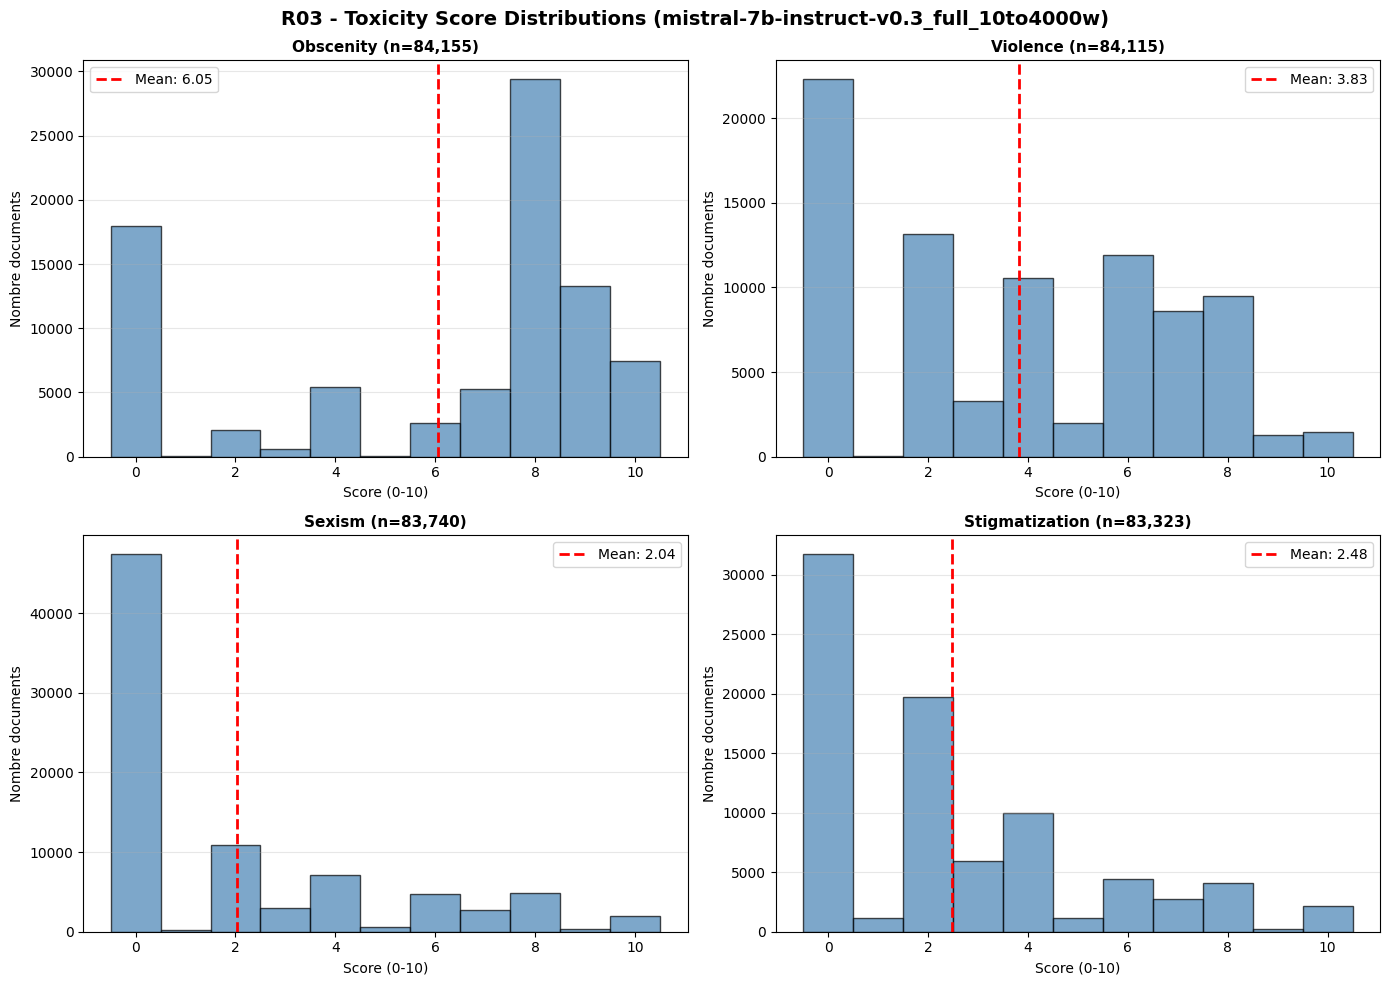


2️⃣  Box plots comparaison dimensions...
  ✓ R03_02_boxplot.png


/tmp/ipykernel_3867115/1696357649.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[d.title() for d in available_dims],


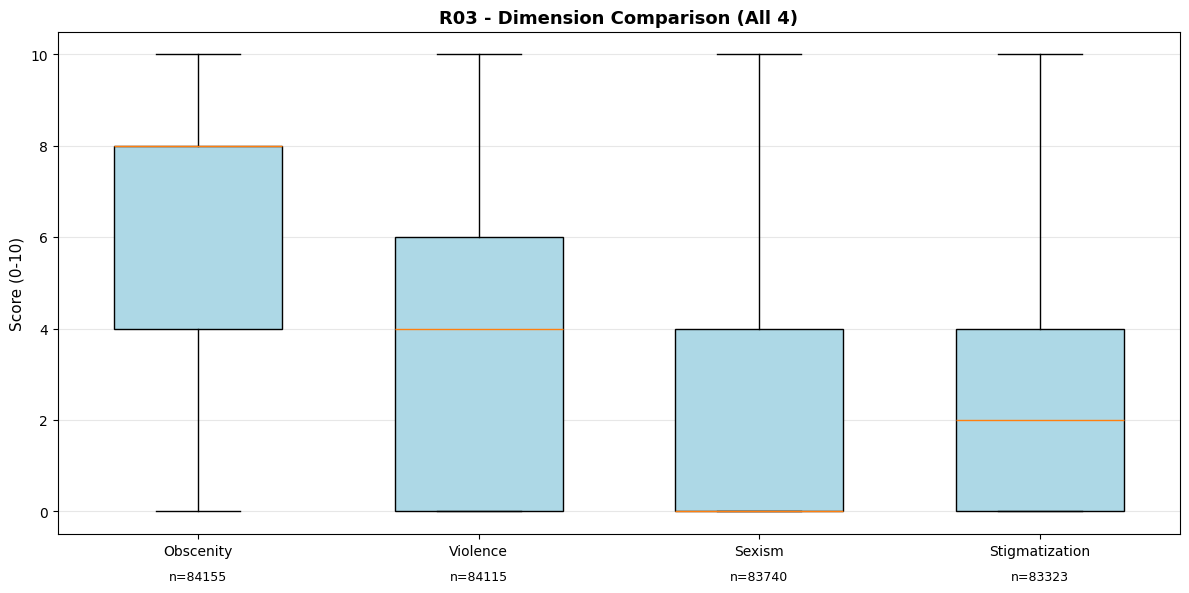


3️⃣  Heatmap de corrélation...
  ✓ R03_03_correlation_heatmap.png


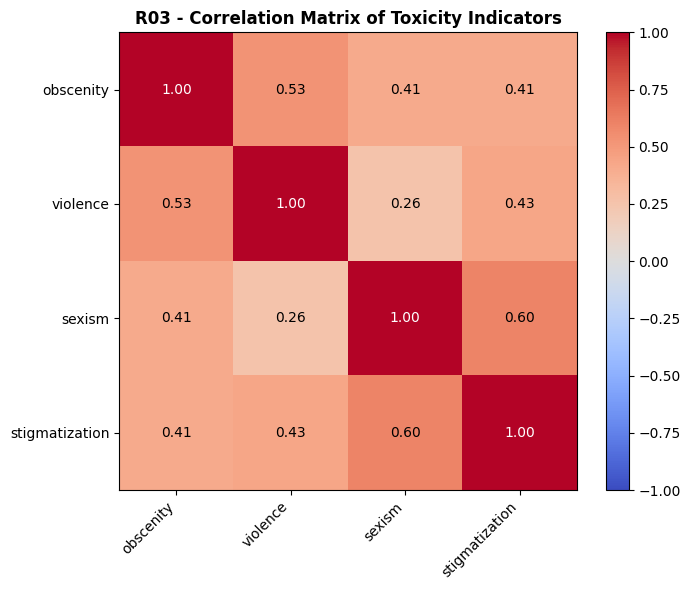


4️⃣  Evolution temporelle par année...
  ✓ R03_04_yearly_trends.png


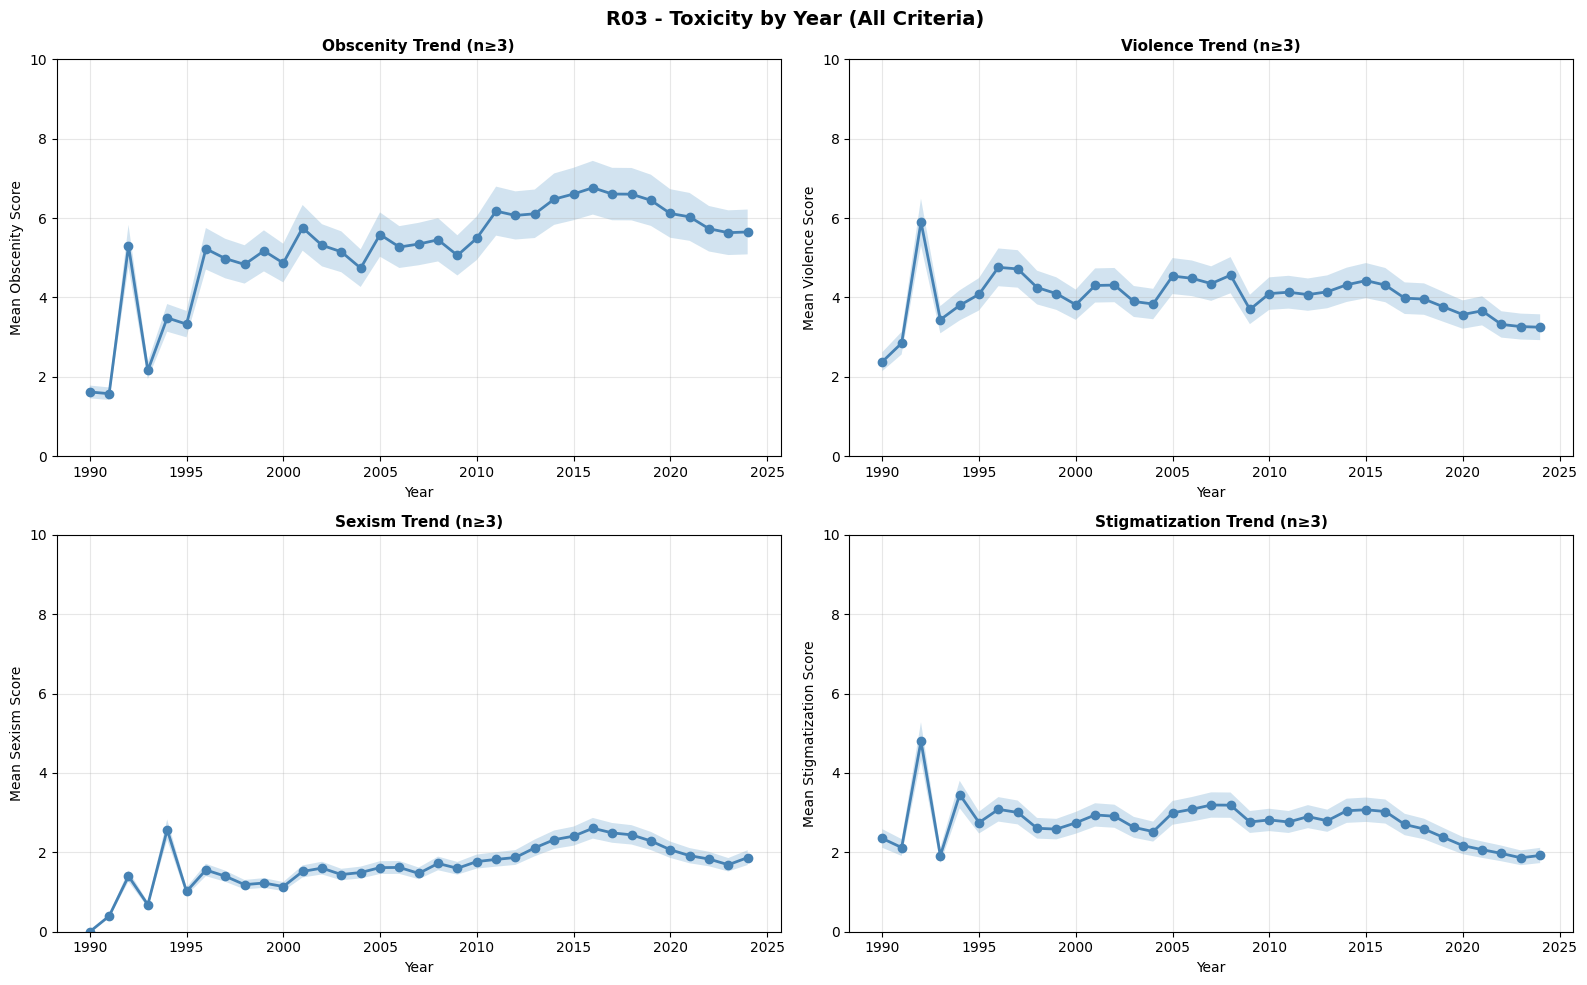


5️⃣  Rapport Complétude des Scores:
  Total documents: 84,155

  OBSCENITY:
    ✓ Scores valides: 84,155 (100.0%)
    ✗ Scores manquants: 0 (0.0%)

  VIOLENCE:
    ✓ Scores valides: 84,115 (100.0%)
    ✗ Scores manquants: 40 (0.0%)

  SEXISM:
    ✓ Scores valides: 83,740 (99.5%)
    ✗ Scores manquants: 415 (0.5%)

  STIGMATIZATION:
    ✓ Scores valides: 83,323 (99.0%)
    ✗ Scores manquants: 832 (1.0%)

✓ Tous les graphiques générés dans ./images/

✅ PIPELINE COMPLÉTÉ


In [52]:
# ============================================================================
# SECTION 7: VISUALISATIONS & ANALYSES RÉSULTATS
# ============================================================================

# Images output directory
images_dir = Path('images')
images_dir.mkdir(exist_ok=True)

print("\n" + "="*70)
print("📊 GENERATING visualizations")
print("="*70)

# --- Utiliser tous les critères définis (4 dimensions)
all_dimensions = ['obscenity', 'violence', 'sexism', 'stigmatization']

# --- 7.1: Distribution scores par dimension
print("\n1️⃣  Distribution histogrammes...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{notebook_prefix} - Toxicity Score Distributions ({run_label})', fontsize=14, fontweight='bold')
axes = axes.flatten()  # Flatten pour itération facile

for idx, dim in enumerate(all_dimensions):
    ax = axes[idx]
    
    if dim in scores_df.columns:
        valid_scores = scores_df[dim].dropna()
        
        # Histogramme avec 11 bins (0-10)
        ax.hist(valid_scores, bins=11, range=(-0.5, 10.5), edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_xlabel('Score (0-10)', fontsize=10)
        ax.set_ylabel('Nombre documents', fontsize=10)
        ax.set_title(f'{dim.title()} (n={len(valid_scores):,})', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Ajouter ligne moyenne
        if len(valid_scores) > 0:
            mean_score = valid_scores.mean()
            ax.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.2f}')
            ax.legend()
    else:
        ax.text(0.5, 0.5, f'{dim}\nNot found in data', ha='center', va='center', fontsize=12, color='red')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
hist_file = images_dir / f'{notebook_prefix}_01_distributions.png'
plt.savefig(hist_file, dpi=150, bbox_inches='tight')
print(f"  ✓ {hist_file.name}")
plt.show()
plt.close()

# --- 7.2: Box plots comparaison dimensions (tous les 4)
print("\n2️⃣  Box plots comparaison dimensions...")
fig, ax = plt.subplots(figsize=(12, 6))

# Préparer données pour box plot - filtrer dimensions existantes
available_dims = [dim for dim in all_dimensions if dim in scores_df.columns]
box_data = [scores_df[dim].dropna() for dim in available_dims]

if box_data:
    bp = ax.boxplot(box_data, labels=[d.title() for d in available_dims],
                      patch_artist=True, widths=0.6)
    
    # Style
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_ylabel('Score (0-10)', fontsize=11)
    ax.set_title(f'{notebook_prefix} - Dimension Comparison (All {len(available_dims)})', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Ajouter nombre de samples
    for idx, dim in enumerate(available_dims, 1):
        valid_count = len(scores_df[dim].dropna())
        ax.text(idx, -1.5, f'n={valid_count}', ha='center', fontsize=9)

plt.tight_layout()
boxplot_file = images_dir / f'{notebook_prefix}_02_boxplot.png'
plt.savefig(boxplot_file, dpi=150, bbox_inches='tight')
print(f"  ✓ {boxplot_file.name}")
plt.show()
plt.close()

# --- 7.3: Heatmap de corrélation entre les 4 indicateurs
print("\n3️⃣  Heatmap de corrélation...")

corr_df = scores_df[all_dimensions].dropna()

if len(corr_df) > 0 and corr_df.shape[1] > 1:
    corr_matrix = corr_df.corr(method='pearson')
    fig, ax = plt.subplots(figsize=(8, 6))
    heatmap = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    ax.set_title(f'{notebook_prefix} - Correlation Matrix of Toxicity Indicators', fontsize=12, fontweight='bold')

    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            value = corr_matrix.iloc[i, j]
            color = 'black' if abs(value) < 0.75 else 'white'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    corr_file = images_dir / f'{notebook_prefix}_03_correlation_heatmap.png'
    plt.savefig(corr_file, dpi=150, bbox_inches='tight')
    print(f"  ✓ {corr_file.name}")
    plt.show()
    plt.close()
else:
    print("  ⚠️  Pas assez de données pour calculer la matrice de corrélation.")

# --- 7.4: Statistiques par année (si data disponible)
if 'year' in scores_df.columns:
    print("\n4️⃣  Evolution temporelle par année...")
    
    # Grouper par année et calculer moyennes - INCLURE TOUS LES 4 CRITÈRES
    yearly_stats = scores_df.groupby('year')[all_dimensions].agg(['mean', 'count'])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{notebook_prefix} - Toxicity by Year (All Criteria)', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    for idx, dim in enumerate(all_dimensions):
        ax = axes[idx]
        
        if dim in yearly_stats.columns:
            # Données avec count >= 3
            year_data = yearly_stats[dim]
            year_data = year_data[year_data['count'] >= 3]
            
            if len(year_data) > 0:
                ax.plot(year_data.index, year_data['mean'], marker='o', linewidth=2, markersize=6, color='steelblue')
                ax.fill_between(year_data.index, year_data['mean'] * 0.9, year_data['mean'] * 1.1, alpha=0.2)
                
                ax.set_xlabel('Year', fontsize=10)
                ax.set_ylabel(f'Mean {dim.title()} Score', fontsize=10)
                ax.set_title(f'{dim.title()} Trend (n≥3)', fontsize=11, fontweight='bold')
                ax.grid(True, alpha=0.3)
                ax.set_ylim(0, 10)
            else:
                ax.text(0.5, 0.5, f'No data for {dim}', ha='center', va='center', fontsize=11)
                ax.set_xticks([])
                ax.set_yticks([])
    
    plt.tight_layout()
    trend_file = images_dir / f'{notebook_prefix}_04_yearly_trends.png'
    plt.savefig(trend_file, dpi=150, bbox_inches='tight')
    print(f"  ✓ {trend_file.name}")
    plt.show()
    plt.close()

# --- 7.5: Rapport complétude des scores
print(f"\n5️⃣  Rapport Complétude des Scores:")
print(f"  Total documents: {len(scores_df):,}")
for dim in all_dimensions:
    if dim in scores_df.columns:
        valid_count = scores_df[dim].notna().sum()
        missing_count = scores_df[dim].isna().sum()
        pct = (valid_count / len(scores_df) * 100) if len(scores_df) > 0 else 0
        print(f"\n  {dim.upper()}:")
        print(f"    ✓ Scores valides: {valid_count:,} ({pct:.1f}%)")
        print(f"    ✗ Scores manquants: {missing_count:,} ({100-pct:.1f}%)")

print("\n✓ Tous les graphiques générés dans ./images/")
print("\n" + "="*70)
print("✅ PIPELINE COMPLÉTÉ")
print("="*70)

## Section 7: Visualizations & Exploratory Analysis

**Purpose:** Generate publication-ready charts and exploratory plots for interpretation.

**Visualizations:**

### 7.1 **Distribution Histograms** (3 subplots)
- One histogram per toxicity dimension (obscenity, violence, sexism)
- 11 bins from 0-10, show mean line
- Reveals score distribution shape and central tendency

### 7.2 **Box Plot Comparison**
- Side-by-side box plots for all 3 dimensions
- Visualize median, quartiles, outliers, and range per dimension
- Enable quick comparison of toxicity levels across categories

### 7.3 **Scatter Plot: Obscenity vs. Violence**
- X/Y axes are two dimensions, points colored by third dimension (sexism)
- Reveal correlations between toxicity factors
- Identify documents with high toxicity in multiple dimensions

### 7.4 **Temporal Trends (Optional)**
- If year metadata available: plot mean toxicity scores by year
- Filter to years with ≥3 documents
- Track how toxicity content evolved over time

**Output:** All figures saved to `./images/` as PNG with 150 DPI